# Hoofdstuk 4: Tuples en lijsten

Waar de basistypes string, int, float en boolean maar één waarde beschrijven, maken we kennis met twee structuren die meer dan één waarde kunnen bevatten: enerzijds het tuple (het ‘koppel’ waarin je twee, drie, vier, … waarden kan samenzetten) en anderzijds de lijst (véél getallen, véél teksten, veel booleans, …).
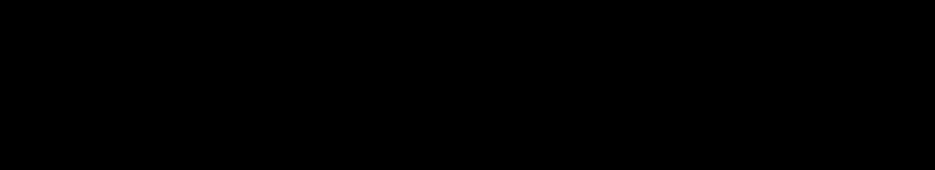
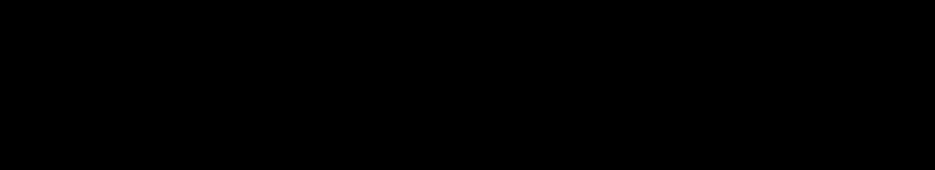

## 4.1 Tuples

Een tuple is een combinatie van waarden tussen ronde haken die je niet kan veranderen: niet van lengte en niet van inhoud. Typische voorbeelden zijn een kleur en vaste coördinaten.

In [ ]:
rood = (255, 0, 0)
geel = (255, 255, 0)
print(f"{rood} en {geel} zijn twee kleuren beschreven als een RGB-tuple")

coordinaten_diepenbeek = (50.9182, 5.4196)
oorsprong_3D = (0, 0, 0)
print(f"En dit zijn twee coördinaten met een ander assenstelsel: {coordinaten_diepenbeek} en {oorsprong_3D}")

Je kan delen van een tuple opvragen door tussen *vierkante* haken de index op te geven. Die telt vanaf 0.

In [ ]:
groenwaarde_van_geel = geel[1]
print(groenwaarde_van_geel)

Als je de cel hieronder uitvoert, zie je dat je een foutmelding krijgt bij het proberen veranderen van een tuple. Je kan natuurlijk wel een nieuw tuple maken door de waarden van een ander tuple te gebruiken.

In [ ]:
# Dit kan
x1 = (4,2)
x1_maal_2 = (x1[0]*2,x1[1]*2)
x1_maal_2_andere_betekenis = x1*2

print(f"{x1_maal_2} is niet hetzelfde als  {x1_maal_2_andere_betekenis}")

x1[0] = 666


### Tuple als returnwaarde van een functie

Tuples worden veel gebruikt om een functie verschillende waarden terug te laten geven. Zo kan je in plaats van één getal, twee of drie getallen tegelijk terug geven. Stel bijvoorbeeld dat je de kleur wil berekenen die van twee kleuren de grootste kleurcomponent neemt, dan zou je volgens het systeem van het vorige hoofdstuk drie functies moeten schrijven: eentje die de maximale rood-waarde berekent, eentje voor groen en eentje voor blauw. Door een tuple terug te geven, kan je die aparte waarden samenvoegen in één tuple en dàt teruggeven.

Onderstaand voorbeeld berekent in één functie zowel de oppervlakte als de omtrek van een rechthoek:

In [ ]:
def opp_omtrek_rechthoek(b, h):
    opp = b * h
    omtrek = 2*(b+h)
    return (opp, omtrek)

opp_omtr = opp_omtrek_rechthoek(4,7)
print(f"De oppervlakte van de rechthoek 4, 7 is {opp_omtr[0]} en de omtrek is {opp_omtr[1]}")


Omdat deze manier van werken zo populair is, heeft men in Python automatisch in- en uitpakken ingebouwd. In essentie houdt dit in dat je geen haakjes rond het tuple moet zetten.



In [ ]:
def opp_omtrek_rechthoek(b, h):
    opp = b * h
    omtrek = 2*(b+h)
    return opp, omtrek

opp, omtrek = opp_omtrek_rechthoek(4,7)
print(f"De oppervlakte van de rechthoek 4, 7 is {opp} en de omtrek is {omtrek}")

### Oefeningen

1. Maak een functie die twee kleurentuples (R, G, B) als parameter krijgt en een kleurentuple teruggeeft met de maximale waarde voor rood, groen en blauw.

In [ ]:
# oef. 1
def maximale_kleur(kleur1, kleur2):
    r = max(kleur1[0], kleur2[0])
    g = max(kleur1[1], kleur2[1])
    b = max(kleur1[2], kleur2[2])

    return (r,g,b)

# zo mag het NIET
#def maximale_kleur_unpacked((r1, g1, b1), (r2, g2, b2)):
#    r = max(r1, r2)
#    g = max(g1, g2)
#    b = max(b1, b2)
#
#    return (r,g,b)

# maar zo wel
def maximale_kleur_unpacked(kleur1, kleur2):
    r1, g1, b1 = kleur1
    r2, g2, b2 = kleur2
    r = max(r1, r2)
    g = max(g1, g2)
    b = max(b1, b2)

    return (r,g,b)

kleur_x = (128, 200, 40)
kleur_y = (255, 0, 128)
kleur_z = maximale_kleur(kleur_x, kleur_y)  # het mag zo
(r_max, g_max, b_max) = maximale_kleur(kleur_x, kleur_y) # maar ook zo

print(f"maximale_kleur({kleur_x}, {kleur_y}) = {kleur_z}")

2. Maak een functie valt_binnen_grenzen die als parameters drie tuples ontvangt:
     - punt: een tuple (x, y) met een meting.
     - x_grenzen: een tuple (min_x, max_x).
     - y_grenzen: een tuple (min_y, max_y).


   De functie moet True teruggeven als de meting binnen beide grenzen valt, anders False.

In [ ]:
def valt_binnen_grenzen(punt, x_grenzen, y_grenzen):
    if not x_grenzen[0] <= punt[0] <= x_grenzen[1]:
        return False
    if not y_grenzen[0] <= punt[1] <= y_grenzen[1]:
        return False
    return True

3. Maak een functie lineaire_interpolatie die als parameters een x bevat en daarnaast twee tuples:
     - kleiner: een tuple (x0, y0) met een x0 die kleiner is dan x
     - groter: een tuple (x1, y1) met een x1 die groter is dan x.

   De functie moet de lineaire interpolatie van y geven voor de bijhorende x.

De lineaire interpolatie bereken je door vanuit x de relatieve afstand tot x0 en x1 te berekenen en die verhouding omgekeerd te gebruiken voor y0 en y1.

- Voorbeeld 1: stel dat $x_0$ gelijk is aan 0 en $x_1$ gelijk aan 10. Wanneer $x$ dan 5 is, de relatieve afstand 50% tot $x_0$ en 50% tot $x_1$. Je moet dan 50% van $y_0$ en 50% van $y_1$ nemen.
- Voorbeeld 2: Wanneer $x_1$ 8 is, is de afstand tot $x_0$ 80% en de afstand tot $x_1$ 20%. Je moet dan 20% van $y_0$ nemen (100%-80%) en 80% van $y_1$ (100%-20%).


In [ ]:
def lineaire_interpolatie(x, kleiner, groter):
    x0, y0 = kleiner
    x1, y1 = groter

    if x0 == x1:  # om in de formule hieronder deling door 0 te vermijden
        return y0

    gewicht = (x - x0) / (x1 - x0)

    y = (1 - gewicht) * y0 + gewicht * y1
    return y

pt1 = (0, 50)
pt2 = (10, 150)
y2 = lineaire_interpolatie(5, pt1, pt2)
y3 = lineaire_interpolatie(8, pt1, pt2)
y4 = lineaire_interpolatie(10, pt1, pt2)

print(f"Lineaire interpolatie op 5: {y2}, op 8: {y3}, op 10: {y4}")